<a href="https://colab.research.google.com/github/max-power-126/lab1_FFNN/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from csv import reader
import time
from torch.utils.data import TensorDataset, DataLoader

# Task 1 – Preprocessing

In [44]:

# D= length avg 3,E=max length 4,F=bytes 5,J=inter arrival time 9,K=packet length 10


data = pd.read_csv("dataset_lab_1.csv",encoding="utf-8")
# Modo corretto ed efficiente in pandas per filtrare i valori uguali a 0 nelle colonne desiderate
rawdata_size= data.shape
######################################## Missing and Duplicate #############################

print(f"dati iniziali",data.shape)
#drop NaN

data.dropna(inplace=True)

print(f"dati No NaN",data.shape)

# Definiamo le colonne che non devono contenere zeri
columns_to_filter = [
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Packet Length Mean'
]

# Creiamo una maschera booleana: per ogni riga, tutte le colonne specificate devono essere diverse da 0
# (data[col] != 0).all(axis=1) verifica che la condizione sia True per TUTTE le colonne selezionate


mask = (data[columns_to_filter] != 0.0).all(axis=1)


# Applichiamo la maschera per ottenere il dataset pulito
data_cleaned = data[mask].copy()

modified_size=data_cleaned.shape

print(f"data filtered= {modified_size}")

data_cleaned.drop_duplicates(inplace=True,keep="first")

print(f"data no duplicate= {data_cleaned.shape}")

# Mostriamo la differenza di righe prima e dopo la pulizia

# 1. Rimuoviamo i valori NaN dal dataset finale


# 2. Rimuoviamo i valori infiniti (inf e -inf)
# Selezioniamo solo le colonne numeriche per verificare la presenza di infiniti
numeric_cols = data_cleaned.select_dtypes(include=[np.number]).columns
is_infinite = np.isinf(data_cleaned[numeric_cols]).any(axis=1)

# Teniamo solo le righe che NON contengono infiniti
data_cleaned_final = data_cleaned[~is_infinite]

print(f"data no inf= {data_cleaned_final.shape}")


#############################Encoded######################################

label_encoder = LabelEncoder()
data_cleaned_final['Label'] = label_encoder.fit_transform(data_cleaned_final['Label'])

data_choosed=data_cleaned_final.copy()

########################################### Split #############################

## train = 60 %, validation = 20 % , test=20%

# Split the dataset
X = data_choosed[['Flow Duration', 'Flow IAT Mean', 'Fwd PSH Flags',
       'Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Flow Bytes/s',
       'Down/Up Ratio', 'SYN Flag Count', 'Fwd Packet Length Mean',
       'Fwd IAT Std', 'Packet Length Mean', 'Fwd Packet Length Max',
       'Subflow Fwd Packets', 'Flow Packets/s', 'Total Fwd Packets',
       'Destination Port']].values
y = data_choosed['Label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



#################### Scaling ################################################
# Standardize the features
scaler = StandardScaler()
X_train_S = scaler.fit_transform(X_train)
X_val_S = scaler.transform(X_val)
X_test_S = scaler.transform(X_test)

print(y_train)
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

########################################################################


dati iniziali (31507, 17)
dati No NaN (31487, 17)
data filtered= (23773, 17)
data no duplicate= (23280, 17)
data no inf= (23280, 17)
[2 3 0 ... 0 0 2]


In [45]:
# @title
# fig, ax = plt.subplots(figsize=(10,5))
# plt.scatter(x=data["Feature_1"].values,
#             y=data["Feature_2"].values,
#             c=data["Label"].values,
#             cmap=plt.cm.RdYlBu)
# plt.show()
# plt.close()

# fig, ax = plt.subplots(figsize=(10,5))
# plt.scatter(x=data["Feature_1"].values,
#             y=data["Feature_2"].values,
#             c=data["Label"].values,
#             cmap=plt.cm.RdYlBu)
# plt.xlim(-2,2)
# plt.ylim(-2,2)
# plt.show()
# plt.close()

# Task 2 – Your first network

## Task 2A

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The device is set to: {device}")

The device is set to: cuda


In [47]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-4
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [48]:
# Define the neural network
class ffnn(nn.Module):
    def __init__(self, input_size, output_size):
        super(ffnn, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_width)
        self.fc2 = nn.Linear(hidden_width, output_size)
        self.relu = activation_function()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [49]:
def training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, num_epochs, min_delta = None, patience = None):
  start_time = time.time()

  train_losses = []
  val_losses = []

  best_val_loss = float('inf')
  trigger_times = 0
  best_model_state = None
  for epoch in range(num_epochs):
    train_loss = 0
    val_loss = 0
    model.train()
    for batch_X, batch_y in train_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)
      optimizer.zero_grad()
      outputs = model(batch_X)
      loss = criterion(outputs, batch_y)
      loss.backward()
      optimizer.step()
      train_loss += loss.item() * batch_X.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        val_outputs = model(batch_X)
        loss = criterion(val_outputs, batch_y)
        val_loss += loss.item() * batch_X.size(0)
      val_loss /= len(val_dataset)
      val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
      print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

    if min_delta is not None:
      if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        trigger_times = 0
      else:
        trigger_times += 1
        if trigger_times >= patience:
          print(f"Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.6f})")
          break
    if best_model_state is not None:
      model.load_state_dict(best_model_state)

  end_time = time.time()
  elapsed_time = end_time - start_time
  print(f'The function took {elapsed_time:.4f} seconds to execute.')

  plt.figure(figsize=(10, 5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.show()

  return

In [50]:
def testing_model(model, dataloader, device):
  start_time = time.time()

  model.eval()
  all_labels = []
  all_predictions = []

  with torch.no_grad():
    for inputs, labels in dataloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = torch.max(outputs, 1)
      all_labels.extend(labels.cpu().numpy())
      all_predictions.extend(predicted.cpu().numpy())
  accuracy = accuracy_score(all_labels, all_predictions) * 100

  end_time = time.time()
  elapsed_time = end_time - start_time
  print(f'The function took {elapsed_time:.4f} seconds to execute.')

  return accuracy


In [51]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [52]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 0.0596, Val Loss: 0.0627
Epoch 40/100, Train Loss: 0.0413, Val Loss: 0.0460
Epoch 60/100, Train Loss: 0.0314, Val Loss: 0.0361
Epoch 80/100, Train Loss: 0.0255, Val Loss: 0.0298
Epoch 100/100, Train Loss: 0.0233, Val Loss: 0.0285
The function took 46.5905 seconds to execute.


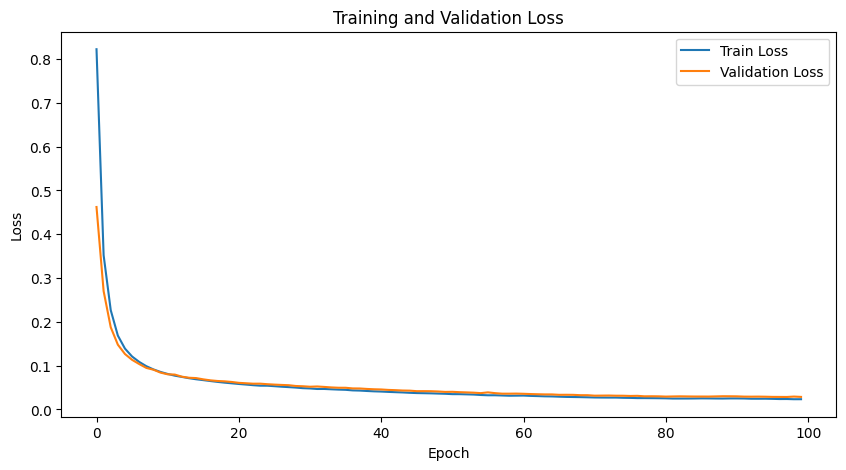

In [53]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [54]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.8608,  0.0389, -0.3020,  ..., -0.2760, -0.3584, -0.5475],
        [-0.1979,  0.0740, -0.3171,  ...,  0.1620, -0.4301,  0.0849],
        [ 0.0081,  0.1584,  0.1975,  ...,  0.1944, -1.3454,  0.2645],
        ...,
        [ 0.1335,  0.0875, -0.2858,  ..., -1.9303,  0.2169, -0.2730],
        [ 0.0729,  0.1061,  0.1757,  ...,  0.2603, -0.1646,  0.1271],
        [ 0.0533, -0.4398, -0.0470,  ..., -0.4373, -0.1075, -0.0572]],
       device='cuda:0')
Learned biases: tensor([ 0.3004,  0.2750, -0.1247,  0.4792,  0.4490, -0.0060,  0.0772, -0.2396,
         0.1386,  0.5542, -0.2044,  0.2970,  0.0757, -0.2069,  0.2556, -0.1605,
        -0.1669,  0.1601,  0.2106,  0.1763,  0.1682,  0.3246,  0.1286, -0.0944,
         0.1949, -0.0307,  0.0479,  0.1979, -0.2466,  0.1814, -0.0292, -0.3080,
         0.3535, -0.2293,  0.1459,  0.5244,  0.1770,  0.6076, -0.1906,  0.3780,
         0.3785,  0.2201, -0.0778,  0.2825,  0.0789,  0.0497,  0.0499,  0.2732,
         0.1466,  0.2929, -0.

In [55]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.1926 seconds to execute.
The function took 0.0610 seconds to execute.
The function took 0.0665 seconds to execute.
Train Accuracy: 99.3986
Validation Accuracy: 99.3771
Test Accuracy: 99.2912


## Task 2B

### S1 – no feature scaling

In [56]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-4
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [57]:
# Convert data to PyTorch tensors and send to CUDA
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

In [58]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [59]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 3426.3835, Val Loss: 4974.3794
Early stopping at epoch 25 (best val loss: 1002.176239)
The function took 12.4805 seconds to execute.


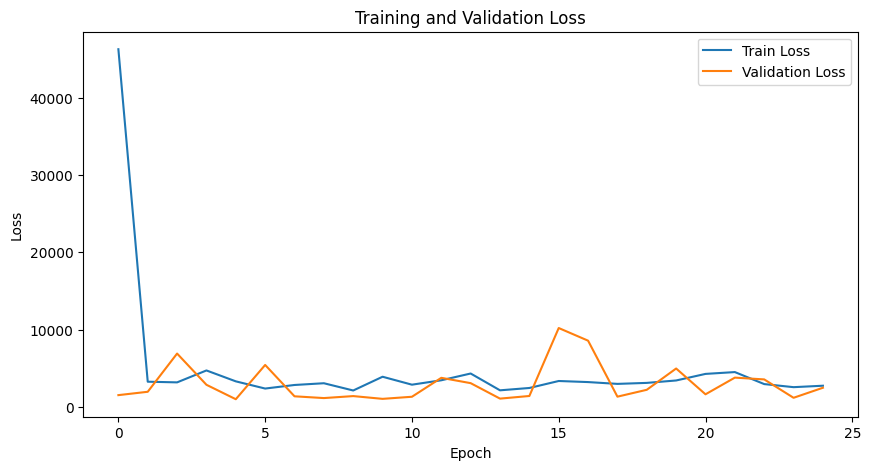

In [60]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [61]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.0349, -0.0795, -0.0077,  ..., -0.0309,  0.2388, -0.0229],
        [-0.2689,  0.2173, -0.1257,  ...,  0.0998,  0.1507,  0.1723],
        [-0.1110,  0.0525,  0.0149,  ...,  0.0670, -0.0036,  0.0795],
        ...,
        [-0.2138, -0.0125, -0.1407,  ..., -0.1169,  0.1494, -0.1503],
        [ 0.0521, -0.0391, -0.0055,  ..., -0.0693, -0.0216,  0.0685],
        [ 0.1509, -0.1132,  0.3913,  ..., -0.1513, -0.1781,  0.1588]],
       device='cuda:0')
Learned biases: tensor([-0.1568, -0.1026,  0.1385, -0.0315, -0.1903,  0.0619, -0.2010,  0.1150,
         0.3218, -0.1909, -0.1824,  0.0115,  0.0482,  0.0868, -0.0692,  0.0455,
        -0.0731,  0.1505,  0.0081, -0.4129,  0.2101, -0.0142, -0.1396,  0.1761,
         0.0789,  0.1311, -0.1650, -0.0976, -0.0437,  0.2008,  0.0344,  0.1702,
         0.2181,  0.0552, -0.1469,  0.0598,  0.0624,  0.1759, -0.0108,  0.4105,
         0.1736, -0.1493,  0.1491, -0.0183, -0.0550,  0.0458, -0.0064, -0.1186,
        -0.1059,  0.1832,  0.

In [62]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.2101 seconds to execute.
The function took 0.0707 seconds to execute.
The function took 0.0674 seconds to execute.
Train Accuracy: 90.8863
Validation Accuracy: 90.8076
Test Accuracy: 89.4115


###  S2 – far too high learning rate

In [63]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-3 # <-------
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [64]:
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [65]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [66]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 0.0349, Val Loss: 0.0381
Epoch 40/100, Train Loss: 0.0242, Val Loss: 0.0249
Epoch 60/100, Train Loss: 0.0223, Val Loss: 0.0317
Epoch 80/100, Train Loss: 0.0213, Val Loss: 0.0264
Early stopping at epoch 81 (best val loss: 0.018378)
The function took 42.8785 seconds to execute.


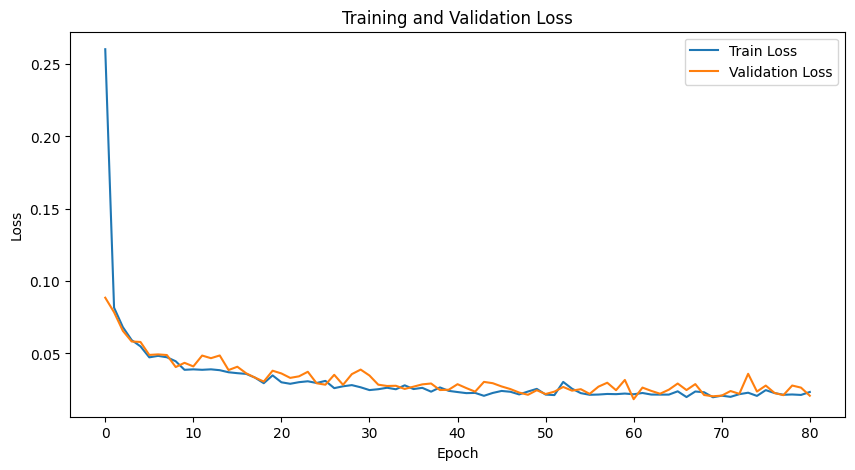

In [67]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [68]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 5.2242e-01,  3.9164e-01,  6.2446e-01,  ..., -7.7140e-02,
         -1.8765e-01,  2.7723e-01],
        [ 2.8268e-01, -9.4336e-02, -1.4119e-01,  ..., -1.8895e-01,
         -1.6227e-01,  1.7126e-01],
        [-2.5210e-01, -2.6185e-01,  7.3142e-02,  ..., -2.6636e+00,
         -1.2169e-01, -6.0192e-04],
        ...,
        [-2.0533e-01, -6.3429e-01, -8.2693e-02,  ..., -1.8537e-01,
         -2.3916e-01,  2.0750e-01],
        [-5.9159e-02,  1.7682e-02, -1.0459e-01,  ...,  2.2830e-01,
         -2.2018e+00, -9.7523e-01],
        [-5.4219e-02, -8.7564e-02, -1.1363e-01,  ...,  4.5705e-01,
         -2.1927e-02, -6.5859e-02]], device='cuda:0')
Learned biases: tensor([-0.2825,  0.0534, -0.0879,  0.2656, -0.0371,  0.2299,  0.6133,  0.3326,
         0.3287,  0.4640,  0.0016, -0.2765,  0.0135,  0.2771, -0.1635, -0.3413,
         0.3706,  0.1232,  0.4740,  0.1902,  0.0585, -0.3861, -0.4046, -0.6958,
         0.2886, -0.5732,  0.1343,  0.2956, -0.0240, -0.2436,  0.3987,  0.0233

In [69]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.4729 seconds to execute.
The function took 0.1713 seconds to execute.
The function took 0.1054 seconds to execute.
Train Accuracy: 99.5776
Validation Accuracy: 99.5490
Test Accuracy: 99.3557


###  S3 – learning rate far too low

In [75]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-7 # <-------
optimizer_algo = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [76]:
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [77]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [78]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer_algo(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 1.3889, Val Loss: 1.3882
Epoch 40/100, Train Loss: 1.3525, Val Loss: 1.3521
Epoch 60/100, Train Loss: 1.3173, Val Loss: 1.3171
Epoch 80/100, Train Loss: 1.2831, Val Loss: 1.2832
Epoch 100/100, Train Loss: 1.2499, Val Loss: 1.2501
The function took 47.5742 seconds to execute.


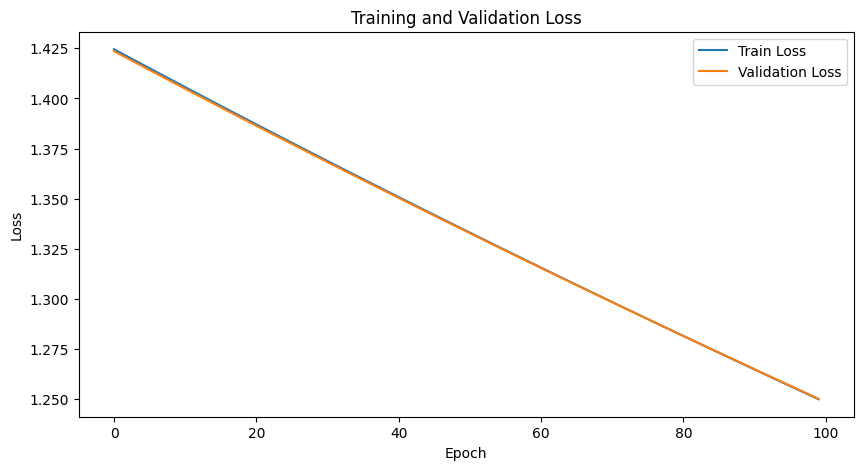

In [79]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [80]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.1703,  0.0788,  0.1795,  ...,  0.1634,  0.0555,  0.2138],
        [ 0.0502,  0.0641,  0.0807,  ..., -0.1876, -0.0848, -0.0870],
        [-0.1887,  0.1661,  0.1795,  ..., -0.0316, -0.0923, -0.2224],
        ...,
        [ 0.1788, -0.0422,  0.1062,  ...,  0.1496, -0.1528,  0.0782],
        [ 0.1588, -0.1630, -0.1538,  ...,  0.0690, -0.1914, -0.0238],
        [ 0.0554,  0.1488, -0.1473,  ...,  0.1546, -0.2080, -0.1569]],
       device='cuda:0')
Learned biases: tensor([-0.0342, -0.2303, -0.0509, -0.0179, -0.0939, -0.2230, -0.0156,  0.1542,
        -0.1762, -0.1539, -0.2569, -0.2311,  0.0831, -0.0608,  0.0907,  0.1207,
         0.2186,  0.1104, -0.1645,  0.1660,  0.0194, -0.1280,  0.0392,  0.0907,
         0.1105, -0.2214, -0.1537,  0.1782, -0.1708, -0.1618, -0.1398,  0.0726,
         0.0407, -0.2334, -0.2155, -0.0580,  0.1632,  0.2325,  0.1484, -0.1426,
        -0.0304, -0.1828, -0.0172,  0.1621, -0.1622, -0.2168,  0.1740,  0.1564,
        -0.2508,  0.1290,  0.

In [81]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.1885 seconds to execute.
The function took 0.0649 seconds to execute.
The function took 0.0735 seconds to execute.
Train Accuracy: 62.2781
Validation Accuracy: 61.9631
Test Accuracy: 62.4785


# Task 3 – When a feature biases the model

In [82]:
X_test_port8080 = X_test.copy()
X_test_port8080[X_test_port8080[:,-1] == 80, -1] = 8080
X_test_S_port8080 = scaler.transform(X_test_port8080)
X_test_tensor_port8080 = torch.tensor(X_test_S_port8080, dtype=torch.float32)
test_dataset_port8080 = TensorDataset(X_test_tensor_port8080, y_test_tensor)
test_loader_port8080 = DataLoader(test_dataset_port8080, batch_size=batch_size, shuffle=False)
test_accuracy_port8080 = testing_model(model,test_loader_port8080,device)
print(f'Test Accuracy: {test_accuracy_port8080:.4f}')


The function took 0.0664 seconds to execute.
Test Accuracy: 62.4570


In [83]:
############ Cleaning ###################################################
columns_to_filter = [
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Packet Length Mean',
    'Destination Port' # <------------------
]
mask = (data[columns_to_filter] != 0.0).all(axis=1)
column_filtered_data = data[mask].copy()

modified_size = column_filtered_data.shape

print(f"Column Filtered Data size = {modified_size}")

no_dup_data = column_filtered_data.drop_duplicates(keep="first")

print(f"data no duplicates = {no_dup_data.shape}")
numeric_cols = no_dup_data.select_dtypes(include=[np.number]).columns
is_infinite = np.isinf(no_dup_data[numeric_cols]).any(axis=1)

# Teniamo solo le righe che NON contengono infiniti
clean_data = no_dup_data[~is_infinite]

print(f"data no inf= {clean_data.shape}")


############ Encoding ######################################

label_encoder = LabelEncoder()
clean_data['Label'] = label_encoder.fit_transform(clean_data['Label'])

encoded_clean_data = clean_data.copy()

############# Split #####################################
## train = 60 %, validation = 20 % , test=20%
X = encoded_clean_data[['Flow Duration', 'Flow IAT Mean', 'Fwd PSH Flags',
       'Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Flow Bytes/s',
       'Down/Up Ratio', 'SYN Flag Count', 'Fwd Packet Length Mean',
       'Fwd IAT Std', 'Packet Length Mean', 'Fwd Packet Length Max',
       'Subflow Fwd Packets', 'Flow Packets/s', 'Total Fwd Packets'
       ]].values
y = encoded_clean_data['Label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#################### Scaling ################################################
scaler = StandardScaler()
X_train_S = scaler.fit_transform(X_train)
X_val_S = scaler.transform(X_val)
X_test_S = scaler.transform(X_test)

print(y_train)
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

Column Filtered Data size = (23773, 17)
data no duplicates = (23280, 17)
data no inf= (23280, 17)
[2 3 0 ... 0 0 2]


# Task 4 – The rare class: loss and imbalance

In [84]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [92]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights) # <---------------
optimizer = optimizer_algo(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 1.2739, Val Loss: 1.2643
Epoch 40/100, Train Loss: 1.2398, Val Loss: 1.2304
Epoch 60/100, Train Loss: 1.2074, Val Loss: 1.1975
Epoch 80/100, Train Loss: 1.1761, Val Loss: 1.1658
Epoch 100/100, Train Loss: 1.1487, Val Loss: 1.1352
The function took 49.6385 seconds to execute.


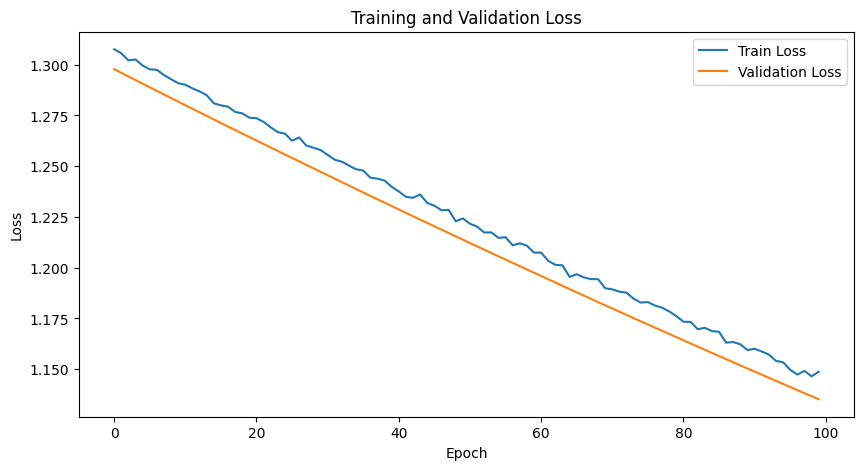

In [93]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [94]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[-0.0391, -0.0370,  0.1412,  0.1468, -0.2408, -0.1951,  0.0628, -0.1360,
         -0.1574, -0.1028,  0.0017, -0.0453, -0.2160,  0.1596,  0.1900],
        [ 0.1419, -0.1192, -0.0902,  0.0984, -0.1013,  0.1197, -0.1452, -0.0216,
          0.1367,  0.1781, -0.2546,  0.2118,  0.1778,  0.1054, -0.0975],
        [-0.2047,  0.2223,  0.0610,  0.0661, -0.1108, -0.1922,  0.2501, -0.0086,
         -0.2165, -0.1994, -0.0648, -0.2106, -0.1966,  0.0025, -0.1004],
        [-0.2340, -0.0209, -0.1063, -0.1968,  0.1247, -0.1500, -0.1304,  0.1117,
          0.0979, -0.1096, -0.1636,  0.1997,  0.2034,  0.0407,  0.2018],
        [ 0.2523,  0.0873, -0.0056, -0.0142,  0.2322,  0.0609, -0.0794, -0.1371,
         -0.1207,  0.1416,  0.1275, -0.2352, -0.0492,  0.0681, -0.2617],
        [ 0.1553, -0.2524,  0.1694,  0.0211, -0.2230, -0.2215,  0.2303,  0.0276,
         -0.1816,  0.1962, -0.0275, -0.1285, -0.0866,  0.2271, -0.1390],
        [ 0.0867,  0.2041, -0.1384,  0.1320,  0.1243, -0.11

In [95]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.2079 seconds to execute.
The function took 0.0676 seconds to execute.
The function took 0.0608 seconds to execute.
Train Accuracy: 66.2514
Validation Accuracy: 66.6237
Test Accuracy: 67.0533
